# 9-1 Seq2Seq 모델

본 노트북은 9-1절 본문 예제 [코드 9-1]~[코드 9-12]를 모아 위에서 아래로 실행해 본다.

다루는 내용
- 입력/출력 어휘 사전과 데이터셋 정의 ([코드 9-1], [코드 9-2])
- 배치 크기 1 데이터로더 ([코드 9-3])
- Seq2Seq 인코더/디코더와 DateConverter 클래스 ([코드 9-4]~[코드 9-9])
- 모델 객체 생성과 학습 함수 ([코드 9-10], [코드 9-11])
- 검증 함수와 학습 루프 (본문 미공개, 노트북에서 정의)
- 학습된 모델로 날짜 문자열 생성 ([코드 9-12])

데이터셋 생성 함수 `generate_datepairs`, `choice_random_dates`는 워크스페이스
`data/data.ipynb`의 본문을 그대로 가져와 노트북 안에서 재정의해 사용한다.

In [21]:
# 참고 - 라이브러리 설치 (이미 설치된 경우 건너뛰어도 좋다)
# 9장 예제는 PyTorch 기본 패키지만으로 동작한다.
# !pip install -q matplotlib numpy torch

In [27]:
# 참고 - 공통 라이브러리 경로 설정
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

viz.configure(save_grayscale=False)

In [28]:
# 참고 - 라이브러리 import 와 시드 고정
SEED = 42
common.set_seed(SEED)
device = common.get_device()

CUDA를 사용합니다.


## 날짜 데이터 생성 (data.ipynb 본문)

본문 [코드 9-1] 직전에 사용하는 `src_dates`/`tgt_dates`는 데이터 생성 함수
두 개의 결과다. 함수 본문은 `data/data.ipynb`에 정의되어 있으며, 재현성과
독립 실행을 위해 노트북에 그대로 옮겨 사용한다.

In [ ]:
# 참고: 데이터 생성 함수
from datetime import datetime, timedelta
import random

src_formats = [
    '%d %B %Y',     # 01 February 2026
    '%d %b %Y',     # 01 Feb 2026
    '%B %d, %Y',    # February 01, 2026
    '%b %d, %Y',    # Feb 01, 2026
    '%m/%d/%Y',     # 02/01/2026
    '%Y/%m/%d',     # 2026/02/01
    '%d-%m-%Y',     # 01-02-2026
    '%Y-%m-%d',     # 2026-02-01
]

# 시작일(start_date)과 종료일(end_date) 사이의 sample_size개의 무작위 날짜 선택
def choice_random_dates(sample_size=1, start_date=None, end_date=None):
    if start_date is None:
        start_date = datetime(1900, 1, 1)
    if end_date is None:
        end_date = datetime(2050, 12, 31)
    days_between = (end_date - start_date).days
    datetime_list = []
    for _ in range(sample_size):
        days_after = random.randrange(days_between)
        datetime_list.append(start_date + timedelta(days=days_after))
    return datetime_list

# datetime 리스트를 입력 리스트와 정답 리스트로 변환하는 함수
# 입력은 src_formats에 정의된 형식으로, 정답은 'YYYY-M-D' 형식으로 변환
def generate_datepairs(date_list, src_formats=src_formats):
    if len(src_formats) == 0:
        raise ValueError('입력 문자열 템플릿이 비어 있습니다.')
    src_dates, tgt_dates = [], []
    for i, date in enumerate(date_list):
        src_format = src_formats[i % len(src_formats)]
        src_dates.append(date.strftime(src_format))
        tgt_dates.append(f'{date.year}-{date.month}-{date.day}')
    return src_dates, tgt_dates


# 4,000개의 (입력, 정답) 날짜 쌍 생성
date_list = choice_random_dates(4000)
src_dates, tgt_dates = generate_datepairs(date_list)
print(f'생성된 날짜 쌍의 수: {len(src_dates)}')

# 입력 -> 정답 예시 (5건)
print('데이터 예시(5건)')
print('    입력 날짜 문자열     -> 정답 날짜 문자열')
for i in range(min(5, len(src_dates))):
    print(f'    {src_dates[i]:<20s} -> {tgt_dates[i]}')

생성된 날짜 쌍의 수: 4000
데이터 예시(5건)
    입력 날짜 문자열     -> 정답 날짜 문자열
    13 February 2002     -> 2002-2-13
    31 Dec 1960          -> 1960-12-31
    August 26, 1962      -> 1962-8-26
    Dec 26, 2029         -> 2029-12-26
    10/08/1907           -> 1907-10-8


## [코드 9-1] 입력과 출력 어휘 사전 생성

글자 단위 토큰에 특수 토큰을 더한 어휘 사전을 클래스로 정의한다. 입력과
출력에 사용하는 토큰 구성이 다르므로 어휘 사전도 입력(`src_vocab`)과
출력(`tgt_vocab`)을 따로 만든다.

In [18]:
###############################################################################
# 코드 9-1 - 입력과 출력 어휘 사전 생성
###############################################################################
# 특수 토큰 관련 상수 및 특수 토큰 딕셔너리
SOS_TOKEN, EOS_TOKEN = '<sos>', '<eos>'
SOS_IDX, EOS_IDX = 0, 1
# 일반적으로 특수 토큰에 데이터와 무관하게 고정된 앞 부분 고유 번호를 부여
special_tokens = {SOS_TOKEN: SOS_IDX, EOS_TOKEN: EOS_IDX}

# 어휘 사전 클래스: 글자 단위 토큰에 특수 토큰을 더한 어휘 사전
class Vocab:
    def __init__(self, sequence_list, special_tokens):
        # tokens: 고유한 토큰의 집합, 중복 제거를 위해 집합 자료형 사용
        tokens = set()
        for sequence in sequence_list:
            tokens.update(sequence)
        # self.vocab: 어휘 사전
        self.vocab = {}
        # 특수 토큰을 어휘 사전에 먼저 추가
        self.vocab.update(special_tokens)
        idx_start = len(special_tokens)
        # 토큰을 정렬 후 순서대로 고유 번호 부여해 어휘 사전에 추가
        for i, token in enumerate(sorted(tokens)):
            self.vocab[token] = i + idx_start
        # self.itos: 역방향 어휘 사전
        self.itos = {idx: token for token, idx in self.vocab.items()}

    # 인코딩 메서드: 문자열 -> 고유 번호 리스트
    def encode(self, input_sequence):
        return [self.vocab[token] for token in input_sequence]

    # 디코딩 메서드: 고유 번호 리스트 -> 토큰 리스트
    def decode(self, input_ids):
        return [self.itos[idx] for idx in input_ids]

    # 어휘 사전의 크기(고유한 토큰의 수)를 반환하는 메서드
    def __len__(self):
        return len(self.vocab)


src_vocab = Vocab(src_dates, special_tokens)  # src: source(입력)의 축약
tgt_vocab = Vocab(tgt_dates, special_tokens)  # tgt: target(정답)의 축약

print(f'입력 어휘 사전 크기: {len(src_vocab)}')
print(f'정답 어휘 사전 크기: {len(tgt_vocab)}')

입력 어휘 사전 크기: 42
정답 어휘 사전 크기: 13


## [코드 9-2] Seq2Seq 모델 학습용 데이터셋 생성

데이터셋은 정답 순차 데이터의 앞뒤에 `<sos>`, `<eos>`를 덧붙여 구성한다.
디코더 입력에는 `[..., :-1]` 슬라이싱으로 `<eos>`를 제외하고, 손실 함수
정답에는 `[..., 1:]` 슬라이싱으로 `<sos>`를 제외해 사용한다.

In [19]:
###############################################################################
# 코드 9-2 - Seq2Seq 모델 학습용 데이터셋 생성
###############################################################################
import torch
from torch.utils.data import Dataset

# 날짜 변환기 모델 학습용 데이터셋 클래스
#    src_dates, src_vocab: 입력 날짜 문자열과 입력 어휘 사전
#    tgt_dates, tgt_vocab: 정답 날짜 문자열과 정답 어휘 사전
class DateDataset(Dataset):
    def __init__(self, src_dates, tgt_dates, src_vocab, tgt_vocab):
        self.samples = []
        for src_date, tgt_date in zip(src_dates, tgt_dates):
            src_ids = src_vocab.encode(src_date)
            tgt_ids = tgt_vocab.encode(tgt_date)
            # 정답 순차 데이터의 앞뒤에 <sos>, <eos> 추가
            #    디코더: <eos> 미포함([..., :-1] 슬라이싱)으로 사용
            #    손실 함수: <sos> 미포함([..., 1:] 슬라이싱)으로 사용
            tgt_ids = [SOS_IDX] + tgt_ids + [EOS_IDX]
            self.samples.append((src_ids, tgt_ids))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        src_ids, tgt_ids = self.samples[idx]
        # 고유번호의 리스트를 long형 텐서로 변환해 반환
        return torch.LongTensor(src_ids), torch.LongTensor(tgt_ids)


# 샘플 수가 각각 3,000개, 1,000개인 훈련 데이터셋과 검증 데이터셋 생성
# 미리 입력과 정답 순차 데이터가 정렬되어 있으므로 순서대로 분리해 사용
train_set = DateDataset(src_dates[:3000], tgt_dates[:3000], 
                        src_vocab, tgt_vocab)
valid_set = DateDataset(src_dates[3000:], tgt_dates[3000:], 
                        src_vocab, tgt_vocab)
print(f'훈련 데이터셋 크기: {len(train_set)}')
print(f'검증 데이터셋 크기: {len(valid_set)}')

# 정답 샘플 텐서의 첫 토큰과 마지막 토큰
tgt_sample = train_set[0][1]
print('정답 샘플 텐서의 첫 토큰:', tgt_sample[0].item())        # <sos> 토큰
print('정답 샘플 텐서의 마지막 토큰:', tgt_sample[-1].item())   # <eos> 토큰

훈련 데이터셋 크기: 3000
검증 데이터셋 크기: 1000
정답 샘플 텐서의 첫 토큰: 0
정답 샘플 텐서의 마지막 토큰: 1


## [코드 9-3] 배치 크기를 1로 지정해 데이터로더 생성

가변 길이 패딩을 9-2절로 미루기 위해, 이번 절에서는 배치 크기를 1로 두어
샘플마다 형태가 달라지는 문제를 잠시 피해 간다.

In [20]:
###############################################################################
# 코드 9-3 - 배치 크기를 1로 지정해 데이터로더 생성
###############################################################################
from torch.utils.data import DataLoader

# 배치에 속한 샘플은 길이가 모두 같아야 하므로 배치 크기 1의 데이터로더 생성
BATCH_SIZE = 1
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)

print(f'배치 크기: {BATCH_SIZE}')
print(f'훈련 데이터로더 배치 수: {len(train_loader)}')
print(f'검증 데이터로더 배치 수: {len(valid_loader)}')

배치 크기: 1
훈련 데이터로더 배치 수: 3000
검증 데이터로더 배치 수: 1000


## [코드 9-4] Seq2Seq 모델의 인코더 클래스

인코더는 임베딩 계층과 LSTM 계층으로 구성된다. `forward()`는 LSTM 계층의
두 번째 반환값 `(hidden, cell)`을 언패킹해 둘 다 반환한다.

- `hidden`: 모든 층의 마지막 숨겨진 상태(단기 기억), `(num_layers, B, hidden_dim)`
- `cell`: 모든 층의 마지막 셀 상태(장기 기억), `(num_layers, B, hidden_dim)`

In [21]:
###############################################################################
# 코드 9-4 - Seq2Seq 모델의 인코더 클래스
###############################################################################
import torch.nn as nn

# 콘텍스트 벡터를 생성하는 인코더(임베딩 계층 -> LSTM 계층으로 구성)
class Encoder(nn.Module):
    def __init__(self, src_vocab_size, embed_dim, hidden_dim, num_layers):
        super().__init__()
        # 임베딩 계층
        self.encoder_embedding = nn.Embedding(src_vocab_size, embed_dim)
        # 순환 신경망(LSTM) 계층
        self.encoder_lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers=num_layers, batch_first=True
        )

    def forward(self, src):                     # src: (B, S) 형태의 텐서
        embedded = self.encoder_embedding(src)  # (B, S) -> (B, S, embed_dim)
        encoder_output, (hidden, cell) = self.encoder_lstm(embedded)
        # encoder_output은 사용하지 않음
        # hidden: (num_layers, B, hidden_dim)
        # cell:   (num_layers, B, hidden_dim)
        return hidden, cell

## [코드 9-5]~[코드 9-8] Seq2Seq 모델의 디코더 클래스

디코더는 세 메서드로 구성된다.

- `__init__` ([코드 9-6]): 임베딩, LSTM, 분류기 선형 계층 정의
- `forward_step` ([코드 9-7]): 한 토큰의 로짓 계산 (마중물 토큰 + 콘텍스트 벡터)
- `forward` ([코드 9-8]): `forward_step`을 정답 길이만큼 반복, 교사 강제 적용

[코드 9-5]는 세 메서드의 시그니처만 보여주는 전체 구조이므로, 아래 셀에서
세 메서드의 본문을 채운 완성 클래스로 한 번에 정의한다.

In [24]:
###############################################################################
# 코드 9-5 ~ 코드 9-8 - Seq2Seq 모델의 디코더 클래스
###############################################################################

# 콘텍스트 벡터를 사용해 순차 데이터를 생성하는 디코더 클래스
#     임베딩 계층 -> LSTM 계층 -> 선형 계층으로 구성
class Decoder(nn.Module):
    # 생성자 메서드: 디코더를 구성하는 계층 정의 ([코드 9-6])
    def __init__(self, tgt_vocab_size, embed_dim, hidden_dim, num_layers):
        super().__init__()
        # 임베딩 계층: 토큰 고유 번호를 임베딩 벡터로 변환
        self.decoder_embedding = nn.Embedding(tgt_vocab_size, embed_dim)
        # LSTM 계층: 생성을 위한 특징 추출 순환 신경망 계층
        self.decoder_lstm = nn.LSTM(
            embed_dim + hidden_dim, hidden_dim, 
            num_layers=num_layers, batch_first=True,
        )
        # 선형 계층: 분류기 계층(다음 토큰의 로짓을 계산)
        self.fc = nn.Linear(hidden_dim, tgt_vocab_size)

    # 입력 토큰 + 콘텍스트 벡터로 다음 토큰의 로짓을 계산 ([코드 9-7])    
    def forward_step(self, token, hidden, cell, context):
        # embedded: 입력 토큰 임베딩 벡터, (B, 1, embed_dim) 형태
        embedded = self.decoder_embedding(token)
        # rnn_input: 입력 토큰 벡터와 콘텍스트 벡터 병합 
        #     (B, 1, embed_dim + hidden_dim) 형태
        rnn_input = torch.cat([embedded, context], dim=-1)
        # 이전 단계의 기억을 물려받도록 (hidden, cell) 튜플을 인자로 전달
        #    output: LSTM 계층의 출력, (B, 1, hidden_dim) 형태
        output, (hidden, cell) = self.decoder_lstm(rnn_input, (hidden, cell))
        # logits: 다음 토큰의 예측 로짓, (B, vocab_size) 형태
        logits = self.fc(output.squeeze(1))  
        return logits, hidden, cell

    # 교사 강제 방식을 적용해 순차 데이터 전체를 생성 ([코드 9-8])
    #     forward_step() 메서드를 반복 호출해 토큰을 하나씩 생성
    #     모델 학습에만 사용하며, 예측 함수는 별도로 구현해 사용
    def forward(self, tgt, hidden, cell, context, forcing_ratio=0.5):
        # 학습 과정에만 사용하는 메서드로, 정답의 길이만큼만 토큰을 예측
        _, T = tgt.shape
        all_logits = []
        token = tgt[:, 0:1]                     # 첫 번째 입력 토큰 (<sos>)
        for i in range(T):
            # logits: 다음 예측 토큰
            logits, hidden, cell = self.forward_step(token, hidden, 
                                                     cell, context)
            all_logits.append(logits.unsqueeze(1))
            # 마지막 단계는 다음 단계에 사용할 마중물 토큰이 필요 없음
            if i + 1 < T:                       
                # 교사 강제 여부 결정 (난수와 비교)
                use_teacher_forcing = random.random() < forcing_ratio
                if use_teacher_forcing:         
                    # 교사 강제: 정답 토큰을 다음 마중물로 사용
                    token = tgt[:, i + 1:i + 2]
                else:                           
                    # 교사 강제하지 않음: 이전 생성 토큰을 다음 마중물로 사용
                    token = logits.argmax(dim=-1, keepdim=True)  
        # 로짓 리스트를 (B, T, vocab_size) 텐서로 병합해 반환
        return torch.cat(all_logits, dim=1)

## [코드 9-9] DateConverter 클래스 (인코더 + 디코더 조합)

인코더 객체와 디코더 객체를 주입받아 조합하는 Seq2Seq 모델 클래스다.
인코더가 만든 `hidden[-1]`을 콘텍스트 벡터로 사용하며, `<eos>`를 제거한
정답을 디코더 입력으로 전달한다.

In [25]:
###############################################################################
# 코드 9-9 - 날짜 변환기 Seq2Seq 모델 클래스
###############################################################################

# 인코더와 디코더를 연결해 Seq2Seq 모델을 구성하는 클래스
class DateConverter(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    # src: (B, S), tgt: (B, T + 1) (<sos>, <eos> 포함)
    def forward(self, src, tgt): 
        # ① 인코딩: 입력(src)을 사용해 콘텍스트 벡터를 생성
        hidden, cell = self.encoder(src)   # (num_layers, B, hidden_dim)
        # 콘텍스트 벡터: 가장 마지막 층([-1])의 숨겨진 상태에 시점 차원 추가
        context = hidden[-1].unsqueeze(1)  # (B, 1, hidden_dim)

        # ② 디코딩: 콘텍스트 벡터와 정답(tgt)으로 출력 로짓을 생성
        # 디코더 입력 생성: <eos>를 제거한 정답
        tgt_input = tgt[:, :-1]            # (B, T) (<sos> 포함, <eos> 미포함)
        # 디코더: tgt_input, context를 사용해 출력 토큰별 점수 로짓 텐서 반환
        #      (hidden, cell은 디코더 LSTM 계층의 초기 상태로 사용됨)
        logits = self.decoder(tgt_input, hidden, cell, context)

        # 교차 엔트로피 손실함수는 토큰별 점수(logits)를 받으므로 그대로 반환
        return logits

## [코드 9-10] DateConverter 모델 객체 생성

인코더와 디코더를 같은 값의 인자로 생성한다. 이 중 `HIDDEN_DIM`과
`NUM_LAYERS`는 인코더 상태를 디코더로 그대로 넘기므로 반드시 같아야 한다.

In [29]:
common.set_seed(SEED)

42

In [31]:
###############################################################################
# 코드 9-10 - DateConverter 모델 객체 생성
###############################################################################
# 하이퍼파라미터 설정
EMBED_DIM = 32    # 인코더와 디코더의 임베딩 차원
HIDDEN_DIM = 32   # 인코더와 디코더 LSTM 계층의 숨겨진 상태 차원
NUM_LAYERS = 1    # LSTM 계층의 num_layers 인자

# 입력과 출력의 어휘 사전 크기
src_vocab_size = len(src_vocab)
tgt_vocab_size = len(tgt_vocab)

# 인코더, 디코더 객체 생성
encoder = Encoder(src_vocab_size, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS)
decoder = Decoder(tgt_vocab_size, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS)

# 인코더와 디코더를 주입해 모델 객체 생성(장치 이동 포함)
model = DateConverter(encoder, decoder).to(device)

print(f'전체 파라미터 수: {common.count_params(model):,}')

전체 파라미터 수: 23,181


## [코드 9-11] 1 에포크 학습 함수와 검증 함수, 학습 루프

본문은 학습 함수 [코드 9-11]만 공개하고 검증 함수와 학습 루프는 깃허브
노트북 참조로 안내한다. 검증 함수는 토큰 단위 손실과 함께 **샘플 단위
정확도**(한 샘플의 모든 토큰이 일치할 때만 정답)를 계산한다.

손실 평균 방식은 9장 정책에 따라 토큰 가중 평균을 사용한다.

In [32]:
###############################################################################
# 코드 9-11 - Seq2Seq 모델 학습의 1 에포크 학습 함수
###############################################################################
def train_epoch(model, train_loader, criterion, optimizer, device=None):
    if device is None:
        device = torch.device('cpu')
    model.train()
    total_loss, token_count = 0.0, 0
    for src, tgt in train_loader:         # tgt: <sos>, <eos> 포함, (B, T + 1)
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        logits = model(src, tgt)          # 순전파: 디코더 호출 시 <eos> 제거
        labels = tgt[:, 1:]               # <sos> 제거, (B, T)
        loss = criterion(                 # 토큰 단위 손실 계산 (형태 정리)
            logits.reshape(-1, logits.size(-1)),  
                                          # (B * T, tgt_vocab_size)로 변형
            labels.reshape(-1),           # (B * T,)로 변형
        )
        loss.backward()                   # 역전파
        # 기울기 클리핑: Seq2Seq 모델은 기울기 폭주 문제가 생기기 쉬움        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()                  # 최적화
        n_tokens = labels.numel()         # 배치에 포함된 토큰의 수
        total_loss += loss.item() * n_tokens
        token_count += n_tokens
    return total_loss / token_count       # 전체 토큰의 평균 손실

In [33]:
# 참고 - 검증 함수

# 토큰 단위 손실 + 샘플 단위 정확도(모든 토큰 일치 시에만 정답)를 함께 반환
@torch.no_grad()
def validation_epoch(model, valid_loader, criterion, device=None):
    if device is None:
        device = torch.device('cpu')
    model.eval()
    total_loss, token_count = 0.0, 0
    correct_size, sample_size = 0, 0
    for src, tgt in valid_loader:
        src, tgt = src.to(device), tgt.to(device)
        logits = model(src, tgt)                # (B, T, vocab_size)
        labels = tgt[:, 1:]                     # <sos> 제거
        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            labels.reshape(-1),
        )
        n_tokens = labels.numel()
        total_loss += loss.item() * n_tokens
        token_count += n_tokens
        # 샘플 단위 정확도: 한 샘플의 모든 토큰이 정답과 일치할 때만 정답
        preds = logits.argmax(dim=-1)           # (B, T)
        sample_correct = (preds == labels).all(dim=1)
        correct_size += sample_correct.sum().item()
        sample_size += src.size(0)
    return total_loss / token_count, correct_size / sample_size * 100.0

In [34]:
# 참고 - 학습 함수

import copy

# 조기 종료 방식으로 모델을 학습하는 학습 루프 함수
def train_loop(model, train_loader, valid_loader, criterion, optimizer,
               epochs, patience, device=None):
    if device is None:
        device = torch.device('cpu')
    model.to(device)
    log = common.EpochLogger(epochs, target_rows=epochs)
    best_valid_loss = float('inf')
    best_state, best_epoch, counter = None, 0, 0
    stopped = False
    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        valid_loss, valid_acc = validation_epoch(model, valid_loader, criterion, device)
        # valid_acc는 이미 백분율 수(0~100)
        log.row(epoch, train_loss, valid_loss, valid_acc)
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch, counter = epoch, 0
        else:
            counter += 1
            if counter >= patience:
                stopped = True
                break
    if best_state is not None:
        model.load_state_dict(best_state)
    log.summary(stopped='조기 종료' if stopped else None)
    return {'log': log, 'best_epoch': best_epoch}

### 모델 학습

배치 크기 1 모델 학습은 본문에서도 약 200초 소요된다. 노트북도 동일한
환경(3,000 훈련 / 1,000 검증)으로 참을성 한계 5의 조기 종료로 학습한다.

In [35]:
# 참고 - 학습 실행 (참을성 한계 patience=5)
import torch.optim as optim

LR = 1e-3
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

EPOCHS = 60
PATIENCE = 5
history = train_loop(
    model, train_loader, valid_loader, criterion, optimizer,
    epochs=EPOCHS, patience=PATIENCE, device=device,
)

epoch    훈련 손실    검증 손실    정확도(%)     시간
 1/60       1.2233       0.8976        0.80%     0:34
 2/60       0.7436       0.6192        8.50%     1:06
 3/60       0.5145       0.4397       24.90%     1:38
 4/60       0.3739       0.3560       34.10%     2:10
 5/60       0.2794       0.2564       54.80%     2:43
 6/60       0.2146       0.2197       60.50%     3:15
 7/60       0.1637       0.1736       64.40%     3:47
 8/60       0.1224       0.1567       73.40%     4:19
 9/60       0.0971       0.1477       72.10%     4:51
10/60       0.0770       0.0857       86.10%     5:23
11/60       0.0616       0.1075       83.20%     5:55
12/60       0.0470       0.0848       88.00%     6:27
13/60       0.0452       0.0607       89.50%     6:59
14/60       0.0342       0.0615       91.60%     7:30
15/60       0.0287       0.0559       91.00%     8:02
16/60       0.0278       0.0543       92.20%     8:34
17/60       0.0203       0.0479       93.40%     9:06
18/60       0.0157       0.0726       90.

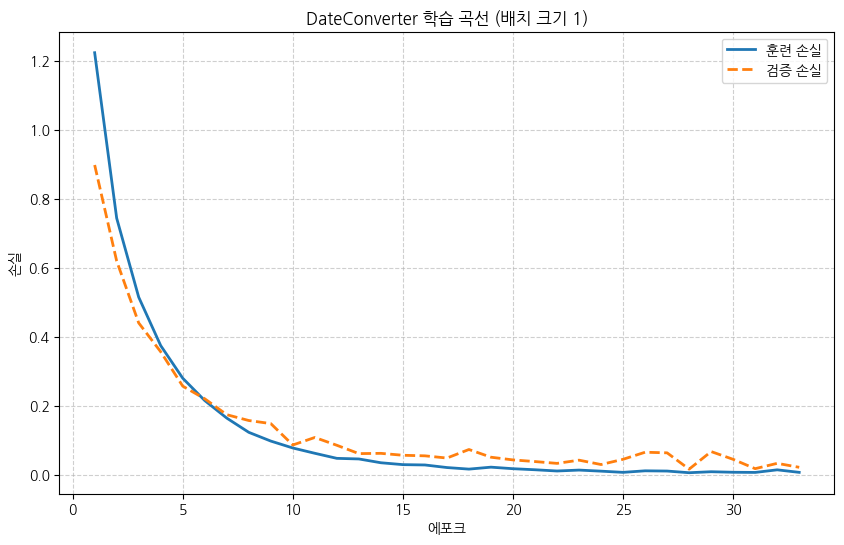

In [36]:
# 참고 - 학습 곡선 시각화 (EpochLogger 내장 plot, §7.7)
history['log'].plot(title='DateConverter 학습 곡선 (배치 크기 1)')

## [코드 9-12] Seq2Seq 모델의 예측(생성) 함수

학습용 `forward()`는 교사 강제를 쓰므로 생성에 쓸 수 없다. 예측 함수는
`<sos>`로 시작해 이전 생성 토큰을 다음 마중물로 사용하며, `<eos>`가 나오거나
`max_length`에 도달할 때까지 토큰을 하나씩 생성한다.

In [37]:
###############################################################################
# 코드 9-12 - Seq2Seq 모델의 예측(생성) 함수
###############################################################################
# 입력 날짜 문자열(src_text)을 출력 날짜 문자열로 변환하는 예측 함수
# <eos> 토큰이 생성되지 않을 때를 대비해 생성 길이 제한 인자(max_length)가 필요
@torch.no_grad()
def predict(model, src_text, src_vocab, tgt_vocab, device=None, max_length=12):
    if device is None:
        device = torch.device('cpu')
    model.eval()
    # 입력 문자열 -> 고유 번호 텐서 (unsqueeze(0)로 배치 차원 추가)
    src_ids = src_vocab.encode(src_text)
    src = torch.LongTensor(src_ids).unsqueeze(0)  # 인코더 입력 텐서
    src = src.to(device)
    # 인코더 - 콘텍스트 벡터(hidden[-1])와 인코더의 상태(hidden, cell) 계산
    hidden, cell = model.encoder(src)
    context = hidden[-1].unsqueeze(1)                     # 콘텍스트 벡터
    # 첫 토큰을 예측하기 위해 <sos>를 디코더 첫 번째 입력 토큰으로 사용
    tgt_token = torch.tensor([[SOS_IDX]]).to(device)      # 디코더 입력 토큰
    result_ids = []
    # forward_step() 메서드를 <eos> 생성 또는 최대 max_length회 반복 호출
    for _ in range(max_length):
        logits, hidden, cell = model.decoder.forward_step(
            tgt_token, hidden, cell, context,
        )
        prediction = logits.argmax(dim=-1, keepdim=True)  # 생성 토큰
        if prediction.item() == EOS_IDX:                  # <eos> 생성 시 종료
            break
        result_ids.append(prediction.item())
        # 예측 시에는 교사 강제 없이 생성된 토큰을 다음 입력으로 사용
        tgt_token = prediction                            # 다음 마중물 토큰
    return ''.join(tgt_vocab.decode(result_ids))


In [38]:
# 참고 - 변환 결과 출력

# show_sample_result(): 샘플 하나의 변환 결과를 출력 형태로 정리하는 헬퍼 함수
def show_sample_result(src_text, tgt_text, predicted_text):
    mark = '정답' if predicted_text == tgt_text else '오답'
    return f'  {src_text:<40s} => {predicted_text} ({mark})'


# 임의의 날짜 하나를 선택해 여덟 종류의 입력 형식으로 테스트 데이터쌍 생성
test_date = choice_random_dates(1) * 8
test_src_dates, test_tgt_dates = generate_datepairs(test_date)
print(f'정답 날짜 문자열: {test_tgt_dates[0]}')
print('  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)')
for src_text, tgt_text in zip(test_src_dates, test_tgt_dates):
    predicted_text = predict(model, src_text, src_vocab, tgt_vocab, device)
    print(show_sample_result(src_text, tgt_text, predicted_text))

정답 날짜 문자열: 2030-5-1
  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)
  01 May 2030                              => 2030-5-1 (정답)
  01 May 2030                              => 2030-5-1 (정답)
  May 01, 2030                             => 2030-5-1 (정답)
  May 01, 2030                             => 2030-5-1 (정답)
  05/01/2030                               => 2030-5-1 (정답)
  2030/05/01                               => 2030-5-1 (정답)
  01-05-2030                               => 2030-5-1 (정답)
  2030-05-01                               => 2030-5-1 (정답)


## 정리

- Seq2Seq 모델은 인코더 LSTM이 만든 콘텍스트 벡터 `hidden[-1]`을 좁은 통로로
  디코더 LSTM에 전달하는 구조다.
- 디코더는 매 시점 `forward_step()`으로 한 토큰씩 생성하며, 학습 단계에서는
  교사 강제 비율로 정답 토큰과 이전 생성 토큰을 섞어 사용한다.
- 배치 크기 1로 학습한 본문의 검증 정확도는 95.80%였다. 노트북도 같은 환경
  에서 유사한 정확도에 도달한다(시드/디바이스 차이로 변동 가능).
- 9-3절 어텐션 노트북에서 노이즈 데이터셋으로 비교 학습한다.

## 긴 입력에서 정보가 희석되는 정보 병목

9-3절 `data.ipynb`의 노이즈 데이터 생성법을 사용해, 입력 날짜 문자열 앞뒤에
무작위 문자를 덧붙인 최대 40자 입력으로 두 가지를 확인한다.

1. (참고) 깨끗한 데이터로 학습한 기존 모델에 노이즈 입력을 넣은 결과
2. 노이즈 데이터로 9-1절 모델을 재학습한 후의 변환 결과

In [40]:
# 참고 1 - 노이즈 데이터 생성 함수(9-3절 data.ipynb 본문 복사) + 기존 모델에 노이즈 입력
# 9-3절에서 사용하는 노이즈 추가 함수. 날짜 문자열 앞뒤에 무작위 문자를 덧붙인다.
import string


def add_random_noise(text, max_length=40):
    # 날짜 문자열 앞뒤에 무작위 노이즈 문자를 덧붙여 최대 40자 입력을 만든다.
    noise_chars = (
        string.ascii_letters + string.digits + '!@#$%^&*()_+-=[]{}|;:,./<>?'
    )
    prefix, suffix = '', ''
    remaining = max_length - len(text)
    if remaining > 0:
        prefix_length = random.randint(0, remaining)
        remaining -= prefix_length
        prefix = ''.join(random.choices(noise_chars, k=prefix_length))
    if remaining > 0:
        suffix_length = random.randint(0, remaining)
        suffix = ''.join(random.choices(noise_chars, k=suffix_length))
    return prefix + text + suffix


def generate_noisy_datepairs(date_list, src_formats=src_formats):
    src_dates, tgt_dates = [], []
    for i, date in enumerate(date_list):
        src_format = src_formats[i % len(src_formats)]
        src_dates.append(add_random_noise(date.strftime(src_format)))
        tgt_dates.append(f'{date.year}-{date.month}-{date.day}')
    return src_dates, tgt_dates


# 깨끗한 날짜로 학습한 기존 model에 노이즈 입력을 넣어 본다.
random.seed(SEED)
test_date = choice_random_dates(1) * 8
noisy_src, noisy_tgt = generate_noisy_datepairs(test_date)

print(f'정답 날짜 문자열: {noisy_tgt[0]}')
print('기존(깨끗한 데이터로 학습한) 모델에 노이즈 입력:')
print('  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)')
for src_text, tgt_text in zip(noisy_src, noisy_tgt):
    try:
        predicted_text = predict(model, src_text, src_vocab, tgt_vocab, device)
        print(show_sample_result(src_text, tgt_text, predicted_text))
    except KeyError as unknown_char:
        # 노이즈 문자는 깨끗한 데이터로 만든 어휘 사전에 없어 인코딩 자체가 실패한다.
        print(f'  {src_text:<40s} => 변환 불가 (어휘 사전에 없는 문자 {unknown_char})')

정답 날짜 문자열: 2014-9-25
기존(깨끗한 데이터로 학습한) 모델에 노이즈 입력:
  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)
  cyt25 September 20148}h                  => 변환 불가 (어휘 사전에 없는 문자 '}')
  ciu1X@!LNy]^o25 Sep 2014En/Dii=1)#V<H    => 변환 불가 (어휘 사전에 없는 문자 'X')
  A3{Grg6&>[]HO-oF7September 25, 2014,52p# => 변환 불가 (어휘 사전에 없는 문자 '{')
  Py:9tSep 25, 2014=*ucCxs,]C              => 변환 불가 (어휘 사전에 없는 문자 'P')
  S{5mm%V%MZG?mR^[no8109/25/2014H?V<[b     => 변환 불가 (어휘 사전에 없는 문자 '{')
  k{%&EAoa##<^Tj3-TrHo.:;2014/09/25RjG>)   => 변환 불가 (어휘 사전에 없는 문자 'k')
  f{.hRg^25-09-2014lQWx                    => 변환 불가 (어휘 사전에 없는 문자 'f')
  1/:^9@J7H|OwfbX0a!ffcDTyRV#2014-09-25vQK => 변환 불가 (어휘 사전에 없는 문자 ':')


In [41]:
# 참고 2 - 노이즈 데이터로 9-1절 모델 재학습 후 변환 결과
# 어휘 사전·데이터셋·데이터로더·모델을 모두 새로 만들어(_noisy) 재학습한다.
# (구조와 하이퍼파라미터는 9-1절과 동일, 어휘 사전 크기만 노이즈 데이터에 맞춤)

# 1) 노이즈 데이터셋 생성 (4,000쌍)
common.set_seed(SEED)  

date_list_noisy = choice_random_dates(4000)
src_dates_noisy, tgt_dates_noisy = generate_noisy_datepairs(date_list_noisy)
print('노이즈 데이터셋 예시:')
for i in range(2):
    print(f'  {src_dates_noisy[i]!r} -> {tgt_dates_noisy[i]!r}')

# 2) 노이즈 문자를 포함하도록 어휘 사전을 다시 생성 (기존 어휘 사전엔 노이즈 문자가 없음)
src_vocab_noisy = Vocab(src_dates_noisy, special_tokens)
tgt_vocab_noisy = Vocab(tgt_dates_noisy, special_tokens)
print(f'입력 어휘 사전 크기: {len(src_vocab)} -> {len(src_vocab_noisy)}')

# 3) 데이터셋과 데이터로더 (배치 크기는 9-1절과 동일)
train_set_noisy = DateDataset(
    src_dates_noisy[:3000], tgt_dates_noisy[:3000], src_vocab_noisy, tgt_vocab_noisy)
valid_set_noisy = DateDataset(
    src_dates_noisy[3000:], tgt_dates_noisy[3000:], src_vocab_noisy, tgt_vocab_noisy)
train_loader_noisy = DataLoader(train_set_noisy, batch_size=BATCH_SIZE, shuffle=True)
valid_loader_noisy = DataLoader(valid_set_noisy, batch_size=BATCH_SIZE, shuffle=False)

# 4) 모델 재생성 후 재학습
encoder_noisy = Encoder(len(src_vocab_noisy), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS)
decoder_noisy = Decoder(len(tgt_vocab_noisy), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS)
model_noisy = DateConverter(encoder_noisy, decoder_noisy).to(device)

optimizer_noisy = optim.Adam(model_noisy.parameters(), lr=LR)
history_noisy = train_loop(
    model_noisy, train_loader_noisy, valid_loader_noisy, criterion, optimizer_noisy,
    epochs=EPOCHS, patience=PATIENCE, device=device,
)

# 5) 변환 결과 - 노이즈 없는 입력과 노이즈 추가 입력 비교 (같은 날짜)
random.seed(SEED)
test_date = choice_random_dates(1) * 8
clean_src, clean_tgt = generate_datepairs(test_date)
noisy_src, noisy_tgt = generate_noisy_datepairs(test_date)

print(f'\n정답 날짜 문자열: {clean_tgt[0]}')
print('노이즈 없는 날짜 문자열 변환:')
print('  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)')
for src_text, tgt_text in zip(clean_src, clean_tgt):
    predicted_text = predict(model_noisy, src_text, src_vocab_noisy, tgt_vocab_noisy, device)
    print(show_sample_result(src_text, tgt_text, predicted_text))

print('\n노이즈를 추가한 날짜 문자열 변환:')
print('  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)')
for src_text, tgt_text in zip(noisy_src, noisy_tgt):
    predicted_text = predict(model_noisy, src_text, src_vocab_noisy, tgt_vocab_noisy, device)
    print(show_sample_result(src_text, tgt_text, predicted_text))

노이즈 데이터셋 예시:
  'uKq5Mc2r0I!s%)25 September 2014Z' -> '2014-9-25'
  ']qDOx[U4120E=2_!A2hlkBq9T24 Dec 19191ZL' -> '1919-12-24'
입력 어휘 사전 크기: 42 -> 92
epoch    훈련 손실    검증 손실    정확도(%)     시간
 1/60       1.4026       1.1923        0.00%     0:34
 2/60       1.1129       1.0519        0.30%     1:08
 3/60       0.9858       0.9390        0.20%     1:41
 4/60       0.8564       0.8243        0.40%     2:13
 5/60       0.7449       0.7149        2.00%     2:44
 6/60       0.6480       0.6293        2.30%     3:16
 7/60       0.5725       0.5580        3.80%     3:48
 8/60       0.5030       0.4880        7.40%     4:20
 9/60       0.4505       0.4872        9.60%     4:52
10/60       0.4048       0.4252       13.80%     5:24
11/60       0.3625       0.3980       20.50%     5:56
12/60       0.3166       0.3468       22.80%     6:28
13/60       0.2800       0.3340       29.20%     7:00
14/60       0.2550       0.3057       37.00%     7:33
15/60       0.2313       0.2893       37.80%     8:12
16

In [43]:

# 깨끗한 날짜로 학습한 기존 model에 노이즈 입력을 넣어 본다.
random.seed(SEED)
test_date = choice_random_dates(1) * 8
noisy_src, noisy_tgt = generate_noisy_datepairs(test_date)

print(f'정답 날짜 문자열: {noisy_tgt[0]}')
print('기존(깨끗한 데이터로 학습한) 모델에 노이즈 입력:')
print('  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)')
for src_text, tgt_text in zip(noisy_src, noisy_tgt):
    try:
        predicted_text = predict(model_noisy, src_text, src_vocab_noisy, tgt_vocab_noisy, device)
        print(show_sample_result(src_text, tgt_text, predicted_text))
    except KeyError as unknown_char:
        # 노이즈 문자는 깨끗한 데이터로 만든 어휘 사전에 없어 인코딩 자체가 실패한다.
        print(f'  {src_text:<40s} => 변환 불가 (어휘 사전에 없는 문자 {unknown_char})')

정답 날짜 문자열: 2014-9-25
기존(깨끗한 데이터로 학습한) 모델에 노이즈 입력:
  입력 날짜 문자열                         => 예측 날짜 문자열 (정답 여부)
  cyt25 September 20148}h                  => 2014-9-25 (정답)
  ciu1X@!LNy]^o25 Sep 2014En/Dii=1)#V<H    => 2014-9-25 (정답)
  A3{Grg6&>[]HO-oF7September 25, 2014,52p# => 2014-9-25 (정답)
  Py:9tSep 25, 2014=*ucCxs,]C              => 2014-9-25 (정답)
  S{5mm%V%MZG?mR^[no8109/25/2014H?V<[b     => 2014-9-24 (오답)
  k{%&EAoa##<^Tj3-TrHo.:;2014/09/25RjG>)   => 2014-9-25 (정답)
  f{.hRg^25-09-2014lQWx                    => 2014-9-25 (정답)
  1/:^9@J7H|OwfbX0a!ffcDTyRV#2014-09-25vQK => 2014-4-25 (오답)
